# Deep Learning Fraud Classification with Optuna and MLflow

Dataset: `train_transaction.csv`.

This notebook builds a binary classification pipeline for `isFraud`, including transaction feature engineering, missing-value handling, categorical encoding, class-imbalance handling, PyTorch neural networks, Optuna tuning, MLflow tracking, and final metric comparison.


## 1. Setup

Fraud detection is imbalanced, so ROC-AUC and PR-AUC are reported alongside threshold-based metrics. `QUICK_RUN` samples rows for faster iteration; set it to `False` for stronger final results.


In [1]:
from pathlib import Path
import sys
import warnings

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

DATA_PATH = PROJECT_ROOT / "train_transaction.csv"
MLFLOW_DB = PROJECT_ROOT / "mlflow.db"
MLFLOW_ARTIFACT_DIR = PROJECT_ROOT / "mlruns"
ARTIFACT_DIR = PROJECT_ROOT / "artifacts"
MODEL_DIR = PROJECT_ROOT / "models"
MLFLOW_ARTIFACT_DIR.mkdir(exist_ok=True)
ARTIFACT_DIR.mkdir(exist_ok=True)
MODEL_DIR.mkdir(exist_ok=True)

QUICK_RUN = False
MAX_ROWS = 100_000 if QUICK_RUN else None
N_TRIALS = 5 if QUICK_RUN else 25
MAX_EPOCHS = 10 if QUICK_RUN else 40
PATIENCE = 3 if QUICK_RUN else 6
RANDOM_STATE = 42

assert DATA_PATH.exists(), f"Dataset not found: {DATA_PATH}"
print("Project root:", PROJECT_ROOT)


Project root: D:\ML-Final Term


In [2]:
import joblib
import mlflow
import mlflow.pytorch
import numpy as np
import optuna
import pandas as pd
import torch
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from src.tabular_dl import (
    MLP,
    ResidualMLP,
    get_device,
    make_loader,
    predict_torch_model,
    seed_everything,
    sigmoid_np,
    to_numpy_dense,
    train_torch_model,
)

seed_everything(RANDOM_STATE)
device = get_device()
MLFLOW_EXPERIMENT = "uas_fraud_deep_learning"
mlflow.set_tracking_uri(f"sqlite:///{MLFLOW_DB.as_posix()}")
if mlflow.get_experiment_by_name(MLFLOW_EXPERIMENT) is None:
    mlflow.create_experiment(MLFLOW_EXPERIMENT, artifact_location=MLFLOW_ARTIFACT_DIR.as_uri())
mlflow.set_experiment(MLFLOW_EXPERIMENT)

def mlflow_safe_params(params):
    return {k: str(v) if isinstance(v, (list, tuple, dict)) else v for k, v in params.items()}

print("Device:", device)
print("MLflow tracking URI:", mlflow.get_tracking_uri())


Device: cpu
MLflow tracking URI: sqlite:///D:/ML-Final Term/mlflow.db


## 2. Load Data and Basic EDA

The target is `isFraud`. The data contains numeric columns, categorical columns, and many missing values.


In [3]:
df = pd.read_csv(DATA_PATH, nrows=MAX_ROWS)

display(df.head())
print("Shape:", df.shape)
display(df["isFraud"].value_counts(normalize=True).rename("ratio"))
display(df["isFraud"].value_counts().rename("count"))


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Shape: (590540, 394)


isFraud
0    0.96501
1    0.03499
Name: ratio, dtype: float64

isFraud
0    569877
1     20663
Name: count, dtype: int64

## 3. Feature Engineering

Added features include transaction hour/day, log transaction amount, and simplified email providers. Columns with more than 95 percent missing values in the training split are removed.


In [4]:
def add_transaction_features(dataframe):
    result = dataframe.copy()
    if "TransactionDT" in result.columns:
        result["transaction_hour"] = (result["TransactionDT"] // 3600) % 24
        result["transaction_day"] = result["TransactionDT"] // (3600 * 24)
    if "TransactionAmt" in result.columns:
        result["transaction_amt_log"] = np.log1p(result["TransactionAmt"])
    for col in ["P_emaildomain", "R_emaildomain"]:
        if col in result.columns:
            result[f"{col}_provider"] = (
                result[col].fillna("missing").astype(str).str.split(".").str[0]
            )
    return result

df_fe = add_transaction_features(df)
y = df_fe["isFraud"].astype("int64")
X_raw = df_fe.drop(columns=["isFraud", "TransactionID"], errors="ignore")

X_train_raw, X_temp_raw, y_train, y_temp = train_test_split(
    X_raw, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)
X_valid_raw, X_test_raw, y_valid, y_test = train_test_split(
    X_temp_raw, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp
)

missing_ratio = X_train_raw.isna().mean()
keep_cols = missing_ratio[missing_ratio < 0.95].index.tolist()
X_train_raw = X_train_raw[keep_cols]
X_valid_raw = X_valid_raw[keep_cols]
X_test_raw = X_test_raw[keep_cols]

categorical_cols = X_train_raw.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
numeric_cols = [col for col in X_train_raw.columns if col not in categorical_cols]

print("Train/valid/test:", X_train_raw.shape, X_valid_raw.shape, X_test_raw.shape)
print("Numeric columns:", len(numeric_cols))
print("Categorical columns:", len(categorical_cols))
print("Positive class ratio train:", y_train.mean())


Train/valid/test: (413378, 397) (88581, 397) (88581, 397)
Numeric columns: 381
Categorical columns: 16
Positive class ratio train: 0.034989767234831076


## 4. Preprocessing

Numeric features are median-imputed and standardized. Categorical features are mode-imputed and one-hot encoded with infrequent categories grouped together.


In [5]:
def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", min_frequency=20, sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", min_frequency=20, sparse=False)

numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)
categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", make_one_hot_encoder()),
    ]
)
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_cols),
        ("cat", categorical_pipeline, categorical_cols),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

X_train = to_numpy_dense(preprocessor.fit_transform(X_train_raw))
X_valid = to_numpy_dense(preprocessor.transform(X_valid_raw))
X_test = to_numpy_dense(preprocessor.transform(X_test_raw))
y_train_np = y_train.to_numpy(dtype="float32")
y_valid_np = y_valid.to_numpy(dtype="float32")
y_test_np = y_test.to_numpy(dtype="float32")

joblib.dump(preprocessor, MODEL_DIR / "fraud_preprocessor.joblib")
print("Processed train/valid/test:", X_train.shape, X_valid.shape, X_test.shape)


Processed train/valid/test: (413378, 608) (88581, 608) (88581, 608)


## 5. Model and Evaluation Helpers

Class imbalance is handled with `pos_weight` in `BCEWithLogitsLoss`. The validation set chooses the probability threshold that maximizes F1, then the threshold is applied to the test set.


In [6]:
negative = float((y_train_np == 0).sum())
positive = float((y_train_np == 1).sum())
POS_WEIGHT = negative / max(positive, 1.0)
print("Positive class weight:", POS_WEIGHT)

def build_model(params, input_dim):
    model_type = params.get("model_type", "mlp")
    dropout = float(params.get("dropout", 0.1))
    batch_norm = bool(params.get("batch_norm", True))
    if model_type == "residual_mlp":
        return ResidualMLP(
            input_dim=input_dim,
            width=int(params.get("width", 128)),
            n_blocks=int(params.get("n_blocks", 3)),
            dropout=dropout,
            batch_norm=batch_norm,
        )
    return MLP(
        input_dim=input_dim,
        hidden_dims=params.get("hidden_dims", [128, 64]),
        dropout=dropout,
        batch_norm=batch_norm,
    )

def find_best_f1_threshold(y_true, probs):
    precision, recall, thresholds = precision_recall_curve(y_true, probs)
    if len(thresholds) == 0:
        return 0.5
    f1_values = 2 * precision * recall / np.maximum(precision + recall, 1e-12)
    best_index = int(np.nanargmax(f1_values[:-1]))
    return float(thresholds[best_index])

def classification_metrics(y_true, probs, threshold):
    preds = (probs >= threshold).astype(int)
    return {
        "roc_auc": roc_auc_score(y_true, probs),
        "pr_auc": average_precision_score(y_true, probs),
        "accuracy": accuracy_score(y_true, preds),
        "precision": precision_score(y_true, preds, zero_division=0),
        "recall": recall_score(y_true, preds, zero_division=0),
        "f1": f1_score(y_true, preds, zero_division=0),
    }

def evaluate_classifier(model, batch_size=1024):
    valid_loader = make_loader(X_valid, y_valid_np, batch_size=batch_size, shuffle=False)
    test_loader = make_loader(X_test, y_test_np, batch_size=batch_size, shuffle=False)
    valid_probs = sigmoid_np(predict_torch_model(model, valid_loader, device=device))
    threshold = find_best_f1_threshold(y_valid_np, valid_probs)
    test_probs = sigmoid_np(predict_torch_model(model, test_loader, device=device))
    metrics = classification_metrics(y_test_np, test_probs, threshold)
    return metrics, threshold, test_probs


Positive class weight: 27.5797842920354


## 6. Train Fixed Architectures

These fixed MLP runs provide a baseline for comparison with the Optuna-tuned architecture.


In [7]:
fixed_architectures = {
    "baseline_mlp": {
        "model_type": "mlp",
        "hidden_dims": [128, 64],
        "dropout": 0.20,
        "batch_norm": True,
        "lr": 1e-3,
        "weight_decay": 1e-5,
        "batch_size": 1024,
    },
    "deep_mlp": {
        "model_type": "mlp",
        "hidden_dims": [256, 128, 64],
        "dropout": 0.30,
        "batch_norm": True,
        "lr": 8e-4,
        "weight_decay": 1e-5,
        "batch_size": 1024,
    },
}

results = []

for run_name, params in fixed_architectures.items():
    seed_everything(RANDOM_STATE)
    batch_size = int(params["batch_size"])
    train_loader = make_loader(X_train, y_train_np, batch_size=batch_size, shuffle=True)
    valid_loader = make_loader(X_valid, y_valid_np, batch_size=batch_size, shuffle=False)
    model = build_model(params, input_dim=X_train.shape[1])

    with mlflow.start_run(run_name=f"fraud_{run_name}"):
        mlflow.log_params(mlflow_safe_params(params))
        mlflow.log_param("max_rows", MAX_ROWS)
        mlflow.log_metric("positive_class_weight", POS_WEIGHT)
        train_result = train_torch_model(
            model,
            train_loader,
            valid_loader,
            task="binary",
            lr=float(params["lr"]),
            weight_decay=float(params["weight_decay"]),
            epochs=MAX_EPOCHS,
            patience=PATIENCE,
            device=device,
            pos_weight=POS_WEIGHT,
        )
        for row in train_result.history:
            mlflow.log_metric("train_loss", row["train_loss"], step=int(row["epoch"]))
            mlflow.log_metric("valid_loss", row["valid_loss"], step=int(row["epoch"]))
        metrics, threshold, _ = evaluate_classifier(model, batch_size=batch_size)
        mlflow.log_metrics(metrics)
        mlflow.log_metric("threshold", threshold)
        mlflow.log_metric("best_valid_loss", train_result.best_valid_loss)
        mlflow.pytorch.log_model(model, name="model", serialization_format="pickle")

    results.append({"model": run_name, **metrics, "threshold": threshold, "best_valid_loss": train_result.best_valid_loss})
    print(run_name, metrics, "threshold", threshold)

pd.DataFrame(results)


2026/06/24 18:07:52 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.


baseline_mlp {'roc_auc': 0.9301745233616661, 'pr_auc': 0.627360809527982, 'accuracy': 0.9753445998577573, 'precision': 0.688039457459926, 'recall': 0.5401742497579864, 'f1': 0.6052060737527115} threshold 0.9097124649690577


2026/06/24 18:13:14 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.


deep_mlp {'roc_auc': 0.9345590506387186, 'pr_auc': 0.6529811425453521, 'accuracy': 0.9758526094760728, 'precision': 0.6869158878504673, 'recall': 0.569215876089061, 'f1': 0.6225516146109052} threshold 0.8751180492837048


,model,roc_auc,pr_auc,accuracy,precision,recall,f1,threshold,best_valid_loss
0,baseline_mlp,0.930175,0.627361,0.975345,0.688039,0.540174,0.605206,0.909712,0.673511
1,deep_mlp,0.934559,0.652981,0.975853,0.686916,0.569216,0.622552,0.875118,0.659217


## 7. Optuna Hyperparameter Tuning

The objective minimizes validation BCE loss. Final model selection still uses business-relevant metrics such as PR-AUC, recall, and F1.


In [8]:
def suggest_params(trial):
    model_type = trial.suggest_categorical("model_type", ["mlp", "residual_mlp"])
    params = {
        "model_type": model_type,
        "dropout": trial.suggest_float("dropout", 0.05, 0.5),
        "batch_norm": trial.suggest_categorical("batch_norm", [True, False]),
        "lr": trial.suggest_float("lr", 1e-4, 3e-3, log=True),
        "weight_decay": trial.suggest_float("weight_decay", 1e-7, 1e-3, log=True),
        "batch_size": trial.suggest_categorical("batch_size", [512, 1024, 2048]),
    }
    if model_type == "residual_mlp":
        params["width"] = trial.suggest_categorical("width", [64, 128, 256])
        params["n_blocks"] = trial.suggest_int("n_blocks", 2, 5)
    else:
        n_layers = trial.suggest_int("n_layers", 2, 4)
        first_width = trial.suggest_categorical("first_width", [128, 256, 512])
        params["hidden_dims"] = [max(first_width // (2 ** i), 32) for i in range(n_layers)]
    return params

def objective(trial):
    seed_everything(RANDOM_STATE + trial.number)
    params = suggest_params(trial)
    batch_size = int(params["batch_size"])
    train_loader = make_loader(X_train, y_train_np, batch_size=batch_size, shuffle=True)
    valid_loader = make_loader(X_valid, y_valid_np, batch_size=batch_size, shuffle=False)
    model = build_model(params, input_dim=X_train.shape[1])

    with mlflow.start_run(run_name=f"fraud_trial_{trial.number}", nested=True):
        mlflow.log_params(mlflow_safe_params(params))
        mlflow.log_metric("positive_class_weight", POS_WEIGHT)
        train_result = train_torch_model(
            model,
            train_loader,
            valid_loader,
            task="binary",
            lr=float(params["lr"]),
            weight_decay=float(params["weight_decay"]),
            epochs=MAX_EPOCHS,
            patience=PATIENCE,
            device=device,
            pos_weight=POS_WEIGHT,
        )
        mlflow.log_metric("best_valid_loss", train_result.best_valid_loss)
        mlflow.log_metric("best_epoch", train_result.best_epoch)
    return train_result.best_valid_loss

with mlflow.start_run(run_name="fraud_optuna_study"):
    study = optuna.create_study(direction="minimize", study_name="fraud_pytorch_tuning")
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)
    mlflow.log_params({f"best_{k}": v for k, v in mlflow_safe_params(study.best_params).items()})
    mlflow.log_metric("best_value", study.best_value)

print("Best value:", study.best_value)
print("Best params:", study.best_params)


[I 2026-06-24 18:13:19,285] A new study created in memory with name: fraud_pytorch_tuning


  0%|          | 0/25 [00:00<?, ?it/s]

[I 2026-06-24 18:16:47,589] Trial 0 finished with value: 0.703455206986525 and parameters: {'model_type': 'residual_mlp', 'dropout': 0.472337117227324, 'batch_norm': True, 'lr': 0.0002932456043110948, 'weight_decay': 0.0005760470626550912, 'batch_size': 512, 'width': 64, 'n_blocks': 3}. Best is trial 0 with value: 0.703455206986525.
[I 2026-06-24 18:20:24,061] Trial 1 finished with value: 0.672710131192417 and parameters: {'model_type': 'residual_mlp', 'dropout': 0.3417449907912345, 'batch_norm': False, 'lr': 0.0017664986003060013, 'weight_decay': 8.768393589069407e-06, 'batch_size': 2048, 'width': 256, 'n_blocks': 3}. Best is trial 1 with value: 0.672710131192417.
[I 2026-06-24 18:24:24,138] Trial 2 finished with value: 0.711159435458312 and parameters: {'model_type': 'residual_mlp', 'dropout': 0.4939140084699406, 'batch_norm': True, 'lr': 0.0003283327633856951, 'weight_decay': 9.654170643801006e-06, 'batch_size': 512, 'width': 64, 'n_blocks': 4}. Best is trial 1 with value: 0.6727101

## 8. Train Final Tuned Model

The best Optuna configuration is retrained and evaluated on the reserved test set using the F1-selected validation threshold.


In [9]:
best_params = suggest_params(optuna.trial.FixedTrial(study.best_params))
seed_everything(RANDOM_STATE)
batch_size = int(best_params["batch_size"])
train_loader = make_loader(X_train, y_train_np, batch_size=batch_size, shuffle=True)
valid_loader = make_loader(X_valid, y_valid_np, batch_size=batch_size, shuffle=False)
best_model = build_model(best_params, input_dim=X_train.shape[1])

with mlflow.start_run(run_name="fraud_optuna_best_model"):
    mlflow.log_params(mlflow_safe_params(best_params))
    mlflow.log_metric("positive_class_weight", POS_WEIGHT)
    train_result = train_torch_model(
        best_model,
        train_loader,
        valid_loader,
        task="binary",
        lr=float(best_params["lr"]),
        weight_decay=float(best_params["weight_decay"]),
        epochs=MAX_EPOCHS,
        patience=PATIENCE,
        device=device,
        pos_weight=POS_WEIGHT,
    )
    for row in train_result.history:
        mlflow.log_metric("train_loss", row["train_loss"], step=int(row["epoch"]))
        mlflow.log_metric("valid_loss", row["valid_loss"], step=int(row["epoch"]))
    metrics, threshold, test_probs = evaluate_classifier(best_model, batch_size=batch_size)
    mlflow.log_metrics(metrics)
    mlflow.log_metric("threshold", threshold)
    mlflow.log_metric("best_valid_loss", train_result.best_valid_loss)
    mlflow.pytorch.log_model(best_model, name="model", serialization_format="pickle")

torch.save(best_model.state_dict(), MODEL_DIR / "fraud_optuna_best_model.pt")
results.append({"model": "optuna_best", **metrics, "threshold": threshold, "best_valid_loss": train_result.best_valid_loss})

results_df = pd.DataFrame(results).sort_values("pr_auc", ascending=False)
display(results_df)
results_df.to_csv(ARTIFACT_DIR / "fraud_results.csv", index=False)


2026/06/24 20:36:39 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.


,model,roc_auc,pr_auc,accuracy,precision,recall,f1,threshold,best_valid_loss
1,deep_mlp,0.934559,0.652981,0.975853,0.686916,0.569216,0.622552,0.875118,0.659217
2,optuna_best,0.932712,0.647348,0.976101,0.701560,0.551468,0.617525,0.892683,0.659411
0,baseline_mlp,0.930175,0.627361,0.975345,0.688039,0.540174,0.605206,0.909712,0.673511


## 9. Confusion Matrix and Discussion

PR-AUC is especially important because fraud is rare. A model can have high accuracy while missing many fraud cases, so compare recall, precision, F1, and the confusion matrix together.


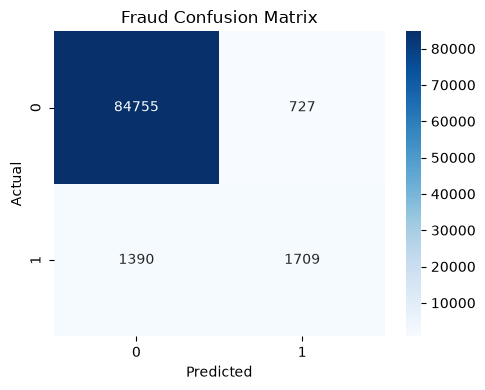

Saved plot to D:\ML-Final Term\artifacts\fraud_confusion_matrix.png


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

test_preds = (test_probs >= threshold).astype(int)
cm = confusion_matrix(y_test_np, test_preds)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Fraud Confusion Matrix")
plt.tight_layout()
plot_path = ARTIFACT_DIR / "fraud_confusion_matrix.png"
plt.savefig(plot_path, dpi=150)
plt.show()
print("Saved plot to", plot_path)


## 10. Conclusion Notes

Use the results table and MLflow run details to explain which model is best. For fraud detection, prioritize PR-AUC, recall, and F1 over accuracy because the class distribution is imbalanced.
